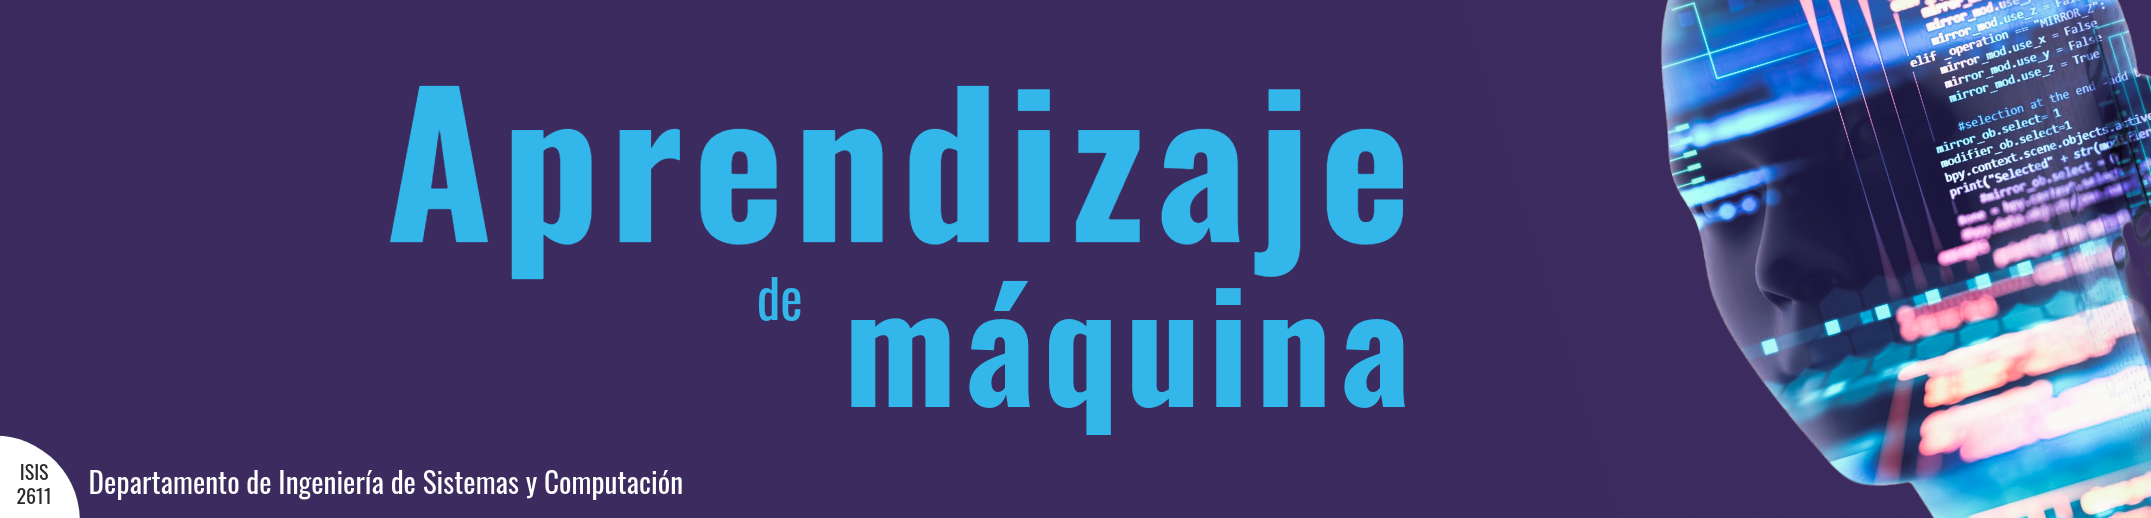

# Laboratorio 4

*Jessica Garay Acosta - CÓDIGO*

*Estefanía Quijano García - 202311445*

## 1. Importaciones

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, silhouette_samples
from sklearn.model_selection import ParameterGrid
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

# Configuración de Visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Exploración de Datos

In [37]:
data = pd.read_csv('./Data/Datos_VuelaAlpes.csv', sep=',')
datos = data.copy()

dict = pd.read_excel('./Data/Diccionario VuelaAlpes.xlsx')
pd.set_option('display.max_colwidth', None)

In [38]:
datos

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
0,119496,Male,Loyal Customer,29,Business travel,Business,814,3,3,3,...,4,4,4,2,5,4,4,4,9,6.0
1,60419,Male,Loyal Customer,54,Business travel,Business,2913,4,4,4,...,4,4,4,4,4,4,4,4,26,9.0
2,9671,Male,Loyal Customer,52,Business travel,Eco,277,4,5,5,...,4,4,4,4,4,3,4,4,68,42.0
3,59115,Female,Loyal Customer,17,Personal Travel,Eco,1744,3,0,3,...,1,4,4,2,5,4,5,4,7,39.0
4,75857,Female,Loyal Customer,30,Personal Travel,Eco,1440,3,4,3,...,3,3,5,5,4,5,4,3,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,90369,Female,Loyal Customer,41,Business travel,Business,240,3,3,3,...,3,3,3,3,3,4,3,4,52,58.0
9996,52337,Male,Loyal Customer,53,Business travel,Eco,261,2,4,4,...,2,2,3,3,1,1,1,2,0,1.0
9997,104932,Male,Loyal Customer,68,Personal Travel,Eco,210,4,2,0,...,5,5,4,4,4,1,3,5,0,0.0
9998,127556,Male,Loyal Customer,52,Personal Travel,Eco Plus,1009,2,4,2,...,5,5,2,5,1,5,2,5,0,0.0


In [39]:
datos.shape

(10000, 23)

In [40]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   id                                 10000 non-null  int64  
 1   Gender                             10000 non-null  object 
 2   Customer Type                      10000 non-null  object 
 3   Age                                10000 non-null  int64  
 4   Type of Travel                     10000 non-null  object 
 5   Class                              10000 non-null  object 
 6   Flight Distance                    10000 non-null  int64  
 7   Inflight wifi service              10000 non-null  int64  
 8   Departure/Arrival time convenient  10000 non-null  int64  
 9   Ease of Online booking             10000 non-null  int64  
 10  Gate location                      10000 non-null  int64  
 11  Food and drink                     10000 non-null  int6

In [41]:
datos.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,9975.000000
mean,64983.058500,39.404300,1196.044800,2.734700,3.074000,2.762600,3.002800,3.215200,3.234500,3.431300,3.361900,3.391000,3.34440,3.635800,3.291700,3.643700,3.281200,14.86020,15.215439
std,37610.205164,15.072364,1000.590808,1.328718,1.520511,1.394287,1.283182,1.324486,1.350293,1.314935,1.329099,1.287123,1.31809,1.184271,1.263951,1.183085,1.311068,36.78467,37.370561
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000
25%,32452.000000,27.000000,416.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,3.000000,2.000000,3.000000,2.000000,0.00000,0.000000
50%,64815.500000,40.000000,846.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.00000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,97470.000000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,5.000000,4.000000,5.000000,4.000000,13.00000,13.000000
max,129879.000000,80.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,930.00000,952.000000


In [42]:
datos.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,9975.000000
mean,64983.058500,39.404300,1196.044800,2.734700,3.074000,2.762600,3.002800,3.215200,3.234500,3.431300,3.361900,3.391000,3.34440,3.635800,3.291700,3.643700,3.281200,14.86020,15.215439
std,37610.205164,15.072364,1000.590808,1.328718,1.520511,1.394287,1.283182,1.324486,1.350293,1.314935,1.329099,1.287123,1.31809,1.184271,1.263951,1.183085,1.311068,36.78467,37.370561
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000
25%,32452.000000,27.000000,416.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,3.000000,2.000000,3.000000,2.000000,0.00000,0.000000
50%,64815.500000,40.000000,846.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.00000,4.000000,3.000000,4.000000,3.000000,0.00000,0.000000
75%,97470.000000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,5.000000,4.000000,5.000000,4.000000,13.00000,13.000000
max,129879.000000,80.000000,4963.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,930.00000,952.000000


In [43]:
dict

,Variable,Tipo,Descripción
0,id,Entero,Identificador único del pasajero
1,Gender,Texto,Género del pasajero (Male / Female)
2,Customer Type,Texto,Tipo de cliente (Loyal Customer / disloyal Customer)
3,Age,Entero,Edad del pasajero
4,Type of Travel,Texto,Tipo de viaje (Business / Personal)
5,Class,Texto,"Clase del vuelo (Eco, Eco Plus, Business)"
6,Flight Distance,Entero,Distancia del vuelo
7,Inflight wifi service,Entero,Calificación del wifi (0–5)
8,Departure/Arrival time convenient,Entero,Conveniencia del horario (0–5)
9,Ease of Online booking,Entero,Facilidad de reserva online (0–5)


## 3. Limpieza de Datos

### Unicidad

In [44]:
datos.duplicated(keep = False).sum()

np.int64(0)

### ID's Duplicados

In [45]:
dup_counts = (datos['id'].value_counts()
              .loc[lambda s: s > 1]
              .sort_values(ascending=False))
print(f"Cantidad de IDs duplicados: {len(dup_counts)}")
for id, n in dup_counts.items():
    print(f"Id={id} → {n} apariciones")

Cantidad de IDs duplicados: 0


### Completitud
Dado que no podemos derivar el retraso en llegada, puesto que es un número independiente y la cantidad de faltantes es mínima, consideramos que el mejor tratamiento es borrarlo.

In [46]:
((datos.isnull().sum()/datos.shape[0])).sort_values(ascending=False)

Arrival Delay in Minutes             0.0025
Online boarding                      0.0000
Departure Delay in Minutes           0.0000
Cleanliness                          0.0000
Inflight service                     0.0000
Checkin service                      0.0000
Baggage handling                     0.0000
Leg room service                     0.0000
On-board service                     0.0000
Inflight entertainment               0.0000
Seat comfort                         0.0000
id                                   0.0000
Gender                               0.0000
Gate location                        0.0000
Ease of Online booking               0.0000
Departure/Arrival time convenient    0.0000
Inflight wifi service                0.0000
Flight Distance                      0.0000
Class                                0.0000
Type of Travel                       0.0000
Age                                  0.0000
Customer Type                        0.0000
Food and drink                  

In [47]:
datos.dropna(subset = ['Arrival Delay in Minutes'], inplace = True)

### Consistencia y Validez
Las variable sde tipo object son:
* Gender
* Customer Type
* Type of Travel
* Class

De las anteriores solo **Type of Travel** presenta inconsistencias según el diccionario. Por ello cambiaresmos *Business travel* por *Business* y *Personal Travel* por *Personal*.

In [48]:
datos['Type of Travel'].value_counts()

Type of Travel
Business travel    6920
Personal Travel    3055
Name: count, dtype: int64

In [49]:
datos.loc[datos['Type of Travel'] == 'Business travel', 'Type of Travel'] = 'Business'
datos.loc[datos['Type of Travel'] == 'Personal Travel', 'Type of Travel'] = 'Personal'

El resto de valores númericos cumplen con las condiciones del diccionario.

### Outliers
Dado que el porcentaje de outliers es alto, se prefiere conservar estos registros para no eliminar su información.

In [50]:
colum = ['Departure Delay in Minutes', 'Arrival Delay in Minutes']

Q1 = datos[colum].quantile(0.25)
Q3 = datos[colum].quantile(0.75)
IQR = Q3 - Q1

outliers = (datos[colum] < (Q1 - 1.5 * IQR)) | (datos[colum] > (Q3 + 1.5 * IQR))
total_outliers = outliers.sum()
porcentaje = (total_outliers / len(datos)) * 100

print("Outliers detectados:")
for col, cnt in total_outliers.items():
    print(f"- {col}: {int(cnt)} ({porcentaje[col]:.2f}%)")

Outliers detectados:
- Departure Delay in Minutes: 1331 (13.34%)
- Arrival Delay in Minutes: 1359 (13.62%)


### Eliminar Variables
Se eliminará la variable **ID** porque no aporta información relevante y, debido a su alta correlación, también se descarta **Departure Delay in Minutes**. En su lugar se conserva **Arrival Delay in Minutes**, ya que un vuelo que despega tarde suele llegar tarde. Además, el retraso en la llegada es el factor que más impacta en la percepción del pasajero.

In [51]:
cols_to_drop = ['ID', 'Departure Delay in Minutes']

datos = datos.drop(columns = cols_to_drop, errors = "ignore")

# Modelamiento
Se implementan tres algoritmos de clustering usando **Pipelines de scikit-learn**, que integran el preprocesamiento con el modelo en un único flujo reproducible.

## Modelo K-Means
Algoritmo de particionamiento que asigna cada punto al centroide más cercano e itera hasta convergencia. Requiere definir `k` (número de clusters) de antemano. Es sensible a outliers y asume clusters esféricos de tamaño similar.

In [52]:
cols_numericas = ['Age', 'Flight Distance', 'Arrival Delay in Minutes', 
                  'Inflight wifi service', 'Departure/Arrival time convenient', 
                  'Ease of Online booking', 'Gate location', 'Food and drink', 
                  'Online boarding', 'Seat comfort', 'Inflight entertainment', 
                  'On-board service', 'Leg room service', 'Baggage handling', 
                  'Checkin service', 'Inflight service', 'Cleanliness']

cols_one_hot = ['Gender', 'Customer Type']
cols_ordinal = ['Type of Travel', 'Class']

**Codificar Variables Categóricas**: Se aplicó One-Hot Encoding a Gender y Customer Type porque son variables nominales sin jerarquía, lo que evita imponer un orden artificial. En cambio, Type of Travel y Class.


**Escalar con RobustScaler()**: El algoritmo usa distancias euclidianas, por lo que es indispensable que todas las variables estén en la misma escala. Además, dado que tenemos algunos valores extremos, se usará `RobustScaler()`.

In [53]:
nav_numerico = Pipeline(steps=[
    ('scaler', RobustScaler())
])

nav_one_hot = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

nav_ordinal = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(handle_unknown = 'use_encoded_value', unknown_value = -1))
])

preprocesador = ColumnTransformer(
    transformers = [
        ('num', nav_numerico, cols_numericas),
        ('cat_nom', nav_one_hot, cols_one_hot),
        ('cat_ord', nav_ordinal, cols_ordinal)
    ])

In [54]:
k_preprocesado = preprocesador.fit_transform(datos)

### Construcción y Evaluación de Modelos

k=2 | Inercia: 114413.6 | Silhouette: 0.5706
k=3 | Inercia: 100352.0 | Silhouette: 0.3661
k=4 | Inercia: 89553.3 | Silhouette: 0.1387
k=5 | Inercia: 84353.5 | Silhouette: 0.1202
k=6 | Inercia: 78543.8 | Silhouette: 0.1184
k=7 | Inercia: 75056.1 | Silhouette: 0.1156
k=8 | Inercia: 72033.3 | Silhouette: 0.1180
k=9 | Inercia: 70147.5 | Silhouette: 0.1139
k=10 | Inercia: 67962.1 | Silhouette: 0.1121


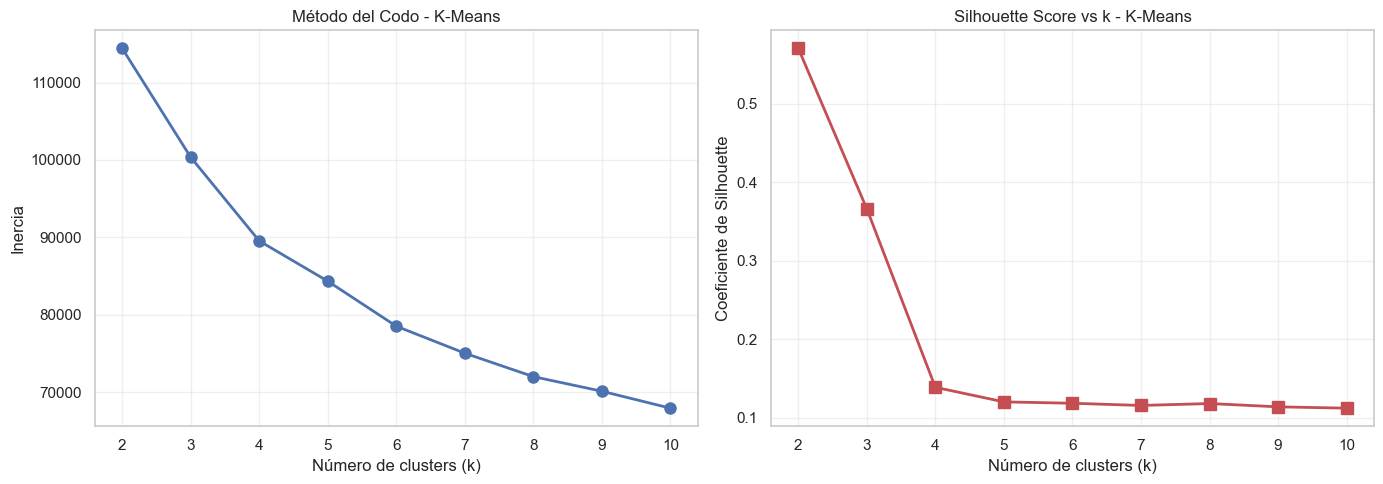


K óptimo según Silhouette: 2


In [55]:
inertias = []
silhouettes = []
k_range = range(2, 11)
RANDOM_STATE = 42

for k in k_range:
    km = KMeans(n_clusters = k, random_state = RANDOM_STATE, n_init=10)
    labels = km.fit_predict(k_preprocesado)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(k_preprocesado, labels, sample_size = 3000, random_state = RANDOM_STATE))
    print(f'k={k} | Inercia: {km.inertia_:.1f} | Silhouette: {silhouettes[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo - K-Means')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Coeficiente de Silhouette')
axes[1].set_title('Silhouette Score vs k - K-Means')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

k_optimo = list(k_range)[np.argmax(silhouettes)]
print(f'\nK óptimo según Silhouette: {k_optimo}')

**Método del Codo**: Para K-Means podemos 

## Modelo DBSCAN
Este algoritmo de clustering está basado en densidad y no requiere especificar el número de clusters, pero sí los parámetros `eps` (radio de vecindad) y `min_samples` (mínimo de puntos para formar un cluster). Se caracteriza por ser robusto a outliers y encontrar clusters de forma arbitraria.

Se realiza el preprocesamiento de los datos, teniendo en cuenta el Pipeline desarrollado en puntos anteriores.

In [ ]:
dbscan_preprocesado = preprocesador.fit_transform(datos)

pca_dbscan = PCA(n_components=15, random_state=42)
dbscan_preprocesado = pca_dbscan.fit_transform(dbscan_preprocesado)

print(f"Varianza explicada acumulada: {pca_dbscan.explained_variance_ratio_.sum():.4f}")
print(f"Shape tras PCA: {dbscan_preprocesado.shape}")

Varianza explicada acumulada: 0.9591
Shape tras PCA: (9975, 15)


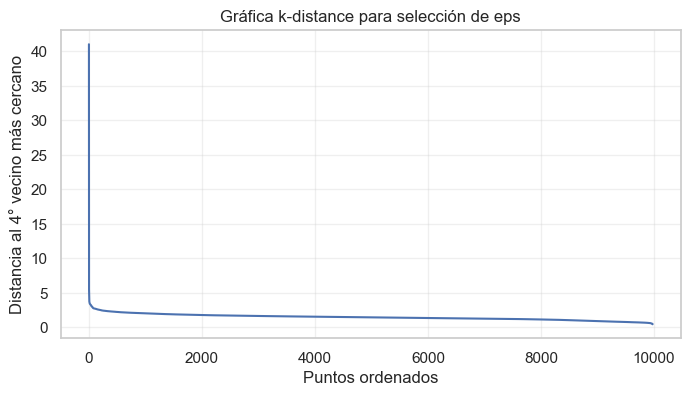

In [ ]:

k = 4
nbrs = NearestNeighbors(n_neighbors=k).fit(dbscan_preprocesado)
distances, _ = nbrs.kneighbors(dbscan_preprocesado)
distancias_k = np.sort(distances[:, k - 1])[::-1]

plt.figure(figsize=(8, 4))
plt.plot(distancias_k)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al {k}° vecino más cercano')
plt.title('Gráfica k-distance para selección de eps')
plt.grid(True, alpha=0.3)
plt.show()

### Búsqueda de hiperparámetros
En primer lugar, se realiza una búsqueda en grilla sobre los parámetros `eps` (de 0.3 a 3.0) y `min_samples` (de 3 a 10). Para cada combinación se entrena un modelo DBSCAN y se calcula el Silhouette Score, siempre que se hayan encontrado al menos 2 clusters. La finalidad de esta experimentación es conservar la configuración con el puntaje más alto.

In [69]:

mejor_silhouette = -1
mejor_eps = None
mejor_min_samples = None
mejor_labels = None
resultados = []

for eps in np.arange(0.5, 5.0, 0.25):
    for min_samples in range(3, 11):
        modelo = DBSCAN(eps=eps, min_samples=min_samples)
        labels = modelo.fit_predict(dbscan_preprocesado)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_ruido = list(labels).count(-1)
        porcentaje_ruido = n_ruido / len(labels)

        if n_clusters > 1 and porcentaje_ruido < 0.30:
            sil = silhouette_score(dbscan_preprocesado, labels)
        else:
            sil = -1

        resultados.append({
            'eps': round(eps, 2),
            'min_samples': min_samples,
            'clusters': n_clusters,
            'ruido': n_ruido,
            'silhouette': sil
        })

        if sil > mejor_silhouette:
            mejor_silhouette = sil
            mejor_eps = eps
            mejor_min_samples = min_samples
            mejor_labels = labels

resultados_df = pd.DataFrame(resultados)
mejores = resultados_df[resultados_df['silhouette'] == resultados_df['silhouette'].max()]
display(mejores)
print(f"Mejor Silhouette: {mejor_silhouette:.4f} | eps={mejor_eps:.2f} | min_samples={mejor_min_samples}")

dbscan_eps = mejor_eps
min_samples_dbscan = mejor_min_samples
dbscan_labels = mejor_labels

,eps,min_samples,clusters,ruido,silhouette
88,3.25,3,2,6,0.818796


Mejor Silhouette: 0.8188 | eps=3.25 | min_samples=3


### Ajuste y evaluación del modelo
Con los hiperparámetros óptimos encontrados, se entrena el modelo final. Se reporta el número de clusters detectados, los puntos clasificados como ruido (etiqueta `-1`) y el Silhouette Score resultante.

In [70]:
dbscan_model = DBSCAN(eps=dbscan_eps, min_samples=min_samples_dbscan)
dbscan_labels = dbscan_model.fit_predict(dbscan_preprocesado)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_dbscan = list(dbscan_labels).count(-1)

print(f'Clusters encontrados por DBSCAN: {n_clusters_dbscan}')
print(f'Puntos considerados ruido: {n_noise_dbscan} ({n_noise_dbscan/len(dbscan_labels)*100:.1f}%)')

if n_clusters_dbscan > 1:
    silhouette_dbscan = silhouette_score(dbscan_preprocesado, dbscan_labels)
    print(f'Silhouette Score DBSCAN: {silhouette_dbscan:.4f}')
else:
    print('No se puede calcular Silhouette Score: menos de 2 clusters.')

Clusters encontrados por DBSCAN: 2
Puntos considerados ruido: 6 (0.1%)
Silhouette Score DBSCAN: 0.8188


### Visualización de clusters
Dado que los datos son de alta dimensionalidad, se aplica PCA para reducirlos a 2 componentes y poder graficarlos. Cada cluster se representa con un color distinto; los puntos de ruido se muestran en negro. Esto permite inspeccionar visualmente la separación y densidad de los grupos encontrados.

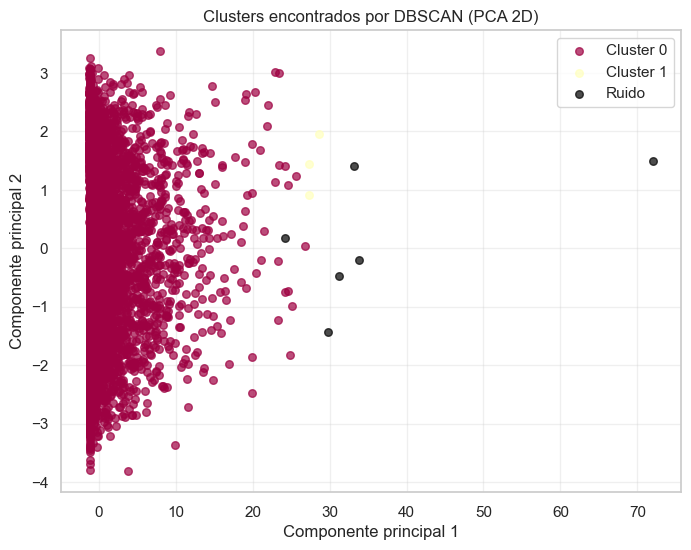

In [71]:
pca_vis = PCA(n_components=2, random_state=42)
dbscan_2d = pca_vis.fit_transform(dbscan_preprocesado)

plt.figure(figsize=(8, 6))
unique_labels = set(dbscan_labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]
    class_member_mask = (dbscan_labels == k)
    plt.scatter(dbscan_2d[class_member_mask, 0], dbscan_2d[class_member_mask, 1],
                c=[col], label=f'Cluster {k}' if k != -1 else 'Ruido', s=30, alpha=0.7)
plt.title('Clusters encontrados por DBSCAN (PCA 2D)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Comparación de algoritmos
Se consolida un resumen de los modelos evaluados con sus hiperparámetros óptimos y el Silhouette Score obtenido. Esta tabla facilita elegir el algoritmo más adecuado según la calidad del agrupamiento y la interpretabilidad de los resultados.

In [72]:
comparacion_algoritmos = pd.DataFrame([
    {"Algoritmo": "K-Means", "Hiperparámetros": f"k={k_optimo}", "Métrica": "Silhouette", "Valor": f"{max(silhouettes):.4f}"},
    {"Algoritmo": "DBSCAN", "Hiperparámetros": f"eps={dbscan_eps:.2f}, min_samples={min_samples_dbscan}", "Métrica": "Silhouette", "Valor": f"{silhouette_dbscan:.4f}" if n_clusters_dbscan > 1 else "N/A"},
])
display(comparacion_algoritmos)

,Algoritmo,Hiperparámetros,Métrica,Valor
0,K-Means,k=2,Silhouette,0.5706
1,DBSCAN,"eps=3.25, min_samples=3",Silhouette,0.8188
